In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
mpg_data = pd.read_csv(r"C:\Users\Venugopal\OneDrive\Desktop\Batch_423\EDA\data\auto-mpg.csv")
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## Auto MPG Dataset: Column Explanations

**mpg**
Miles per gallon (MPG), a measure of fuel efficiency for the car. Higher values indicate better fuel economy.

**cylinders**
The number of cylinders in the engine, typically 4, 6, or 8. More cylinders generally indicate a more powerful engine.

**displacement**
Engine displacement in cubic inches. It refers to the total volume of air/fuel mixture an engine can draw in during one cycle.

**horsepower**
The engine’s power output, measured in horsepower. Higher values indicate more powerful engines.

**weight**
The vehicle’s weight in pounds. Heavier vehicles generally have lower fuel efficiency.

**acceleration**
The time it takes for the car to accelerate from 0 to 60 mph, measured in seconds. Lower values indicate quicker acceleration.

**model year**
The year the car model was released. Ranges from 1970 to 1982 in the dataset.

**origin**
The region where the car was manufactured. 1 = USA, 2 = Europe, 3 = Japan.

**car name**
The name of the car model.


In [4]:
mpg_data.shape

(398, 9)

In [5]:
mpg_data.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [5]:
mpg_data['car name'].nunique()

305

In [6]:
mpg_data=mpg_data.drop(['car name'],axis=1)

In [18]:
del mpg_data['car name']

In [7]:
mpg_data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1
394,44.0,4,97.0,52,2130,24.6,82,2
395,32.0,4,135.0,84,2295,11.6,82,1
396,28.0,4,120.0,79,2625,18.6,82,1


In [8]:
mpg_data['origin'].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

In [9]:
mpg_data['origin']=mpg_data['origin'].map({1:'USA',2:'Europe',3:'Japan'})
mpg_data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,USA
1,15.0,8,350.0,165,3693,11.5,70,USA
2,18.0,8,318.0,150,3436,11.0,70,USA
3,16.0,8,304.0,150,3433,12.0,70,USA
4,17.0,8,302.0,140,3449,10.5,70,USA
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,USA
394,44.0,4,97.0,52,2130,24.6,82,Europe
395,32.0,4,135.0,84,2295,11.6,82,USA
396,28.0,4,120.0,79,2625,18.6,82,USA


In [10]:
mpg_data['origin'].value_counts()

origin
USA       249
Japan      79
Europe     70
Name: count, dtype: int64

In [11]:
mpg_data.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

### 1. What is the distribution of MPG in the dataset? (with hist & kde)


<Axes: xlabel='mpg', ylabel='Count'>

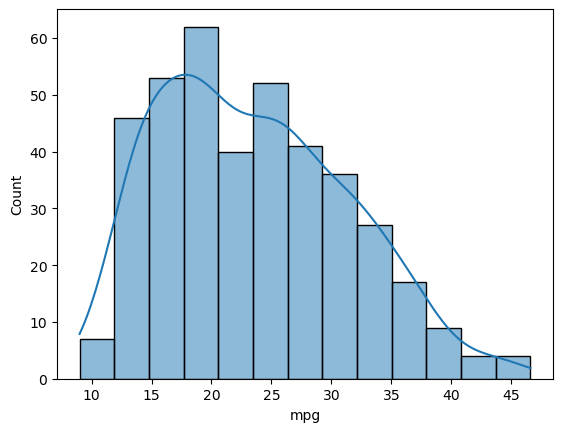

In [12]:
sns.histplot(data=mpg_data,x='mpg',label ='MPG',kde=True)

### 2. How many cars are from each origin (USA, Europe, Japan)?


<Axes: xlabel='origin', ylabel='count'>

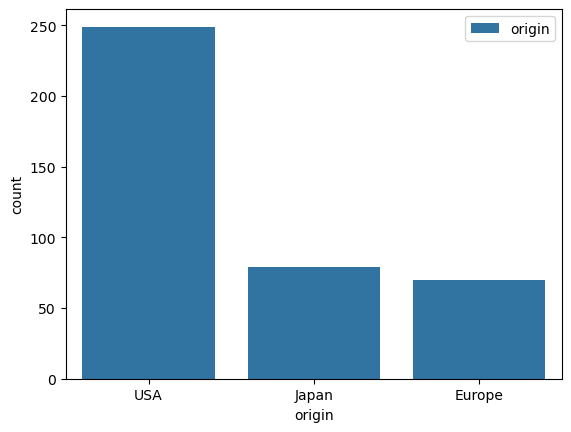

In [13]:
sns.countplot(data=mpg_data,x='origin',label='origin')

### 3. What is proportion of  cars are from each origin (USA, Europe, Japan)?

In [16]:
cars_count=mpg_data['origin'].value_counts()

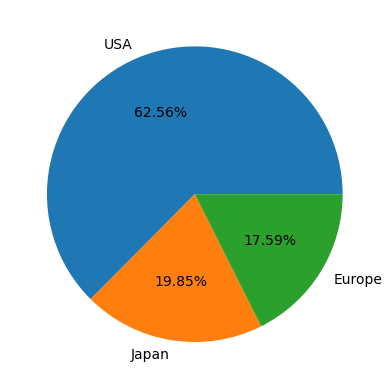

In [19]:
plt.pie(x=cars_count,labels=cars_count.index,autopct='%0.2f%%')
plt.show()

### 3. What percentage of cars belong to each cylinder category?


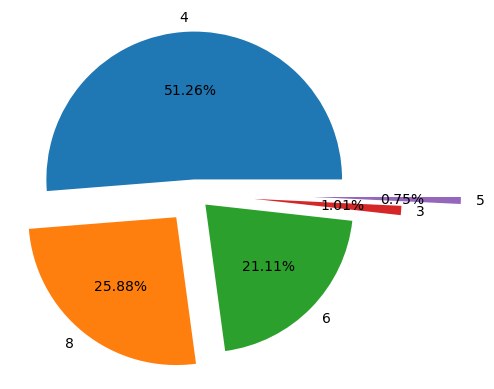

In [26]:
cars_count=mpg_data['cylinders'].value_counts()                           
plt.pie(x=cars_count,labels=cars_count.index,autopct='%0.2f%%',explode=[0.1,0.2,0.1,0.4,0.8])
plt.show()

### 4. What is the relationship between horsepower and weight of cars?


In [30]:
mpg_data[mpg_data['horsepower'] == '?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
32,25.0,4,98.0,?,2046,19.0,71,USA
126,21.0,6,200.0,?,2875,17.0,74,USA
330,40.9,4,85.0,?,1835,17.3,80,Europe
336,23.6,4,140.0,?,2905,14.3,80,USA
354,34.5,4,100.0,?,2320,15.8,81,Europe
374,23.0,4,151.0,?,3035,20.5,82,USA


In [31]:
mpg_data['horsepower']=mpg_data['horsepower'].replace("?",np.nan)

In [33]:
print(mpg_data['horsepower'].isnull().sum())

6


In [34]:
mpg_data[mpg_data['horsepower'] == '?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin


In [37]:
mpg_data['horsepower']=pd.to_numeric(mpg_data['horsepower'])

In [40]:
print(mpg_data['horsepower'].mean())

104.46938775510205


In [38]:
mpg_data[['horsepower','weight']].dtypes

horsepower    float64
weight          int64
dtype: object

In [41]:
mpg_data['horsepower']=mpg_data['horsepower'].fillna(mpg_data['horsepower'].mean())

In [42]:
mpg_data['horsepower'].isnull().sum()

np.int64(0)

In [43]:
mpg_data[['horsepower','weight']].corr()

,horsepower,weight
horsepower,1.000000,0.860574
weight,0.860574,1.000000


### 5. How does MPG vary across different numbers of cylinders?


<Axes: xlabel='cylinders', ylabel='mpg'>

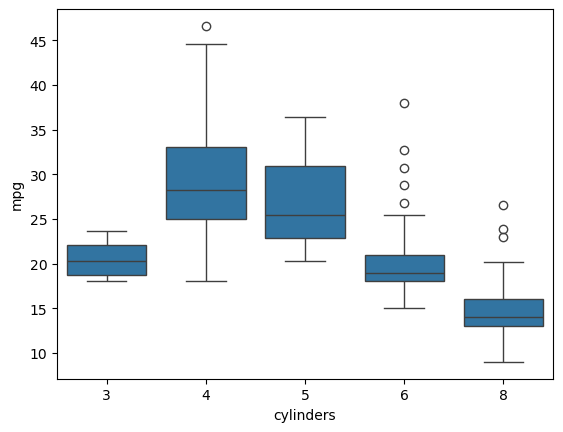

In [44]:
sns.boxplot(data=mpg_data,x='cylinders',y='mpg')

### 6. What are the relationships among horsepower, and acceleration ?


In [45]:
mpg_data[['horsepower','acceleration']].corr()

,horsepower,acceleration
horsepower,1.000000,-0.684259
acceleration,-0.684259,1.000000


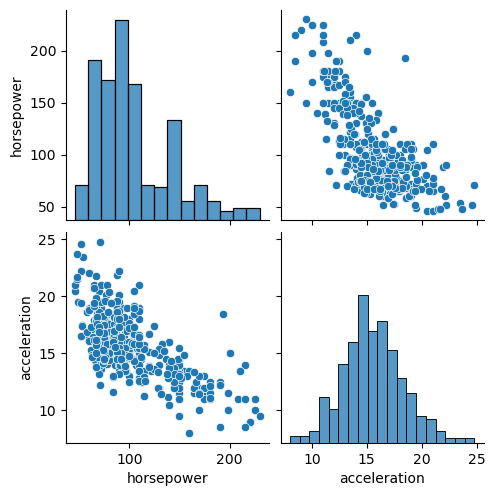

In [46]:
sns.pairplot(mpg_data[['horsepower','acceleration']])

### 7. How does horsepower vary by origin?


<Axes: xlabel='origin', ylabel='horsepower'>

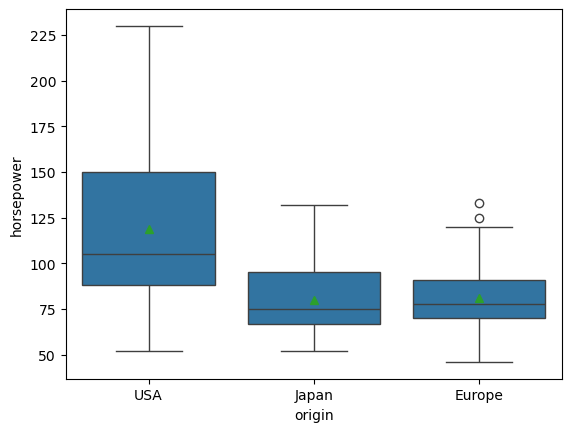

In [48]:
sns.boxplot(data=mpg_data,x='origin',y='horsepower',showmeans=True)

### 8. What is the trend of MPG across different model years?


In [51]:
mpg_data.groupby('model year')['mpg'].mean()

model year
70    17.689655
71    21.250000
72    18.714286
73    17.100000
74    22.703704
75    20.266667
76    21.573529
77    23.375000
78    24.061111
79    25.093103
80    33.696552
81    30.334483
82    31.709677
Name: mpg, dtype: float64

<Axes: xlabel='model year'>

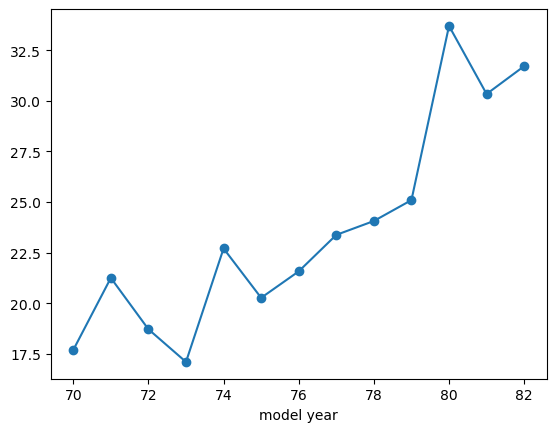

In [53]:
mpg_data.groupby('model year')['mpg'].mean().plot(kind='line',marker='o')

### 9. What is the distribution of displacement in the dataset?


<Axes: xlabel='displacement', ylabel='Count'>

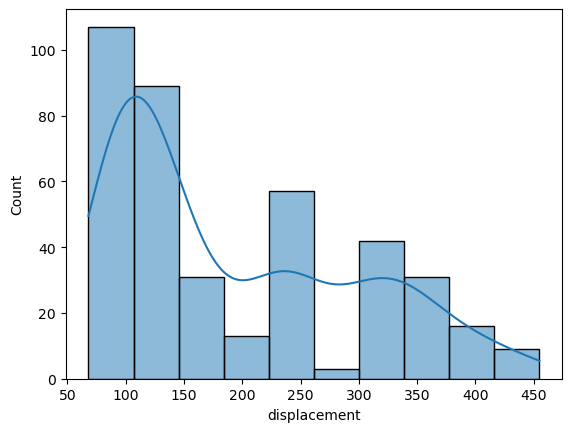

In [56]:
sns.histplot(data=mpg_data,x='displacement',kde=True)

### 10. What is the relationship between MPG and acceleration?


### 11. What relationships can be inferred between MPG, horsepower, and weight?


### 12. What is the distribution of MPG for different car origins?


### 13. What is the distribution of acceleration among various origin of cars?


### 14. How does the weight of cars vary by their origin?


### 15. What is the relationship between MPG and horsepower?


### 16. How does the weight affect the mpg